# 03 · Corrected same-view response KD and controlled ablation

This notebook debugs the negative result from Notebook 02 before introducing another distillation
family. It answers two causal questions:

1. Does the KD training pipeline reduce to the hard-label control when `lambda=0`?
2. Does response KD help when the teacher and student receive the **same augmented image view**?

The default run trains `lambda0_equivalence`, `same_view_lambda0`, and `same_view_t2_l025`.
The corrected hard-label run is required so the same-view KD effect is not confused with the
saturation-range correction. Additional registered ablations are opt-in.
Test data never controls training, model selection, or threshold selection.

## Experimental decision path

```mermaid
flowchart TD
    A[Load frozen manifest, teacher, control, initialization] --> B[Audit IDs and cached logits]
    B --> C[Verify KD math and tensor shapes]
    C --> D[Single-batch and gradient audit]
    D --> E[Train lambda=0 equivalence control]
    E --> F{Equivalent to Notebook 01?}
    F -->|No| G[Stop: repair pipeline]
    F -->|Yes| H[Train same-view T=2 lambda=0.25]
    H --> I[Validation-selected thresholds]
    I --> J[Paired frozen-test comparison]
    J --> K{Float gates pass?}
    K -->|No| L[Retain as negative evidence]
    K -->|Yes| M[INT8 conversion and parity]
```

The same-view path augments one 160x160 source view, gives it directly to the teacher, and
bilinearly downsamples that exact view to 120x120 for the student.

## 1 · Environment and immutable experiment contract

In [1]:
import os
from pathlib import Path

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/vww-matplotlib")

ROOT = Path.cwd()
while not (ROOT / "configs").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
assert (ROOT / "configs").exists(), "Run this notebook from inside the repository."

import sys
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

In [2]:
import copy
import hashlib
import json
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import yaml
from IPython.display import display
from sklearn.metrics import average_precision_score, confusion_matrix, f1_score

from vww_esp32.evaluation import (
    classification_metrics,
    expected_calibration_error,
    select_threshold,
)
from vww_esp32.exporting import convert_full_integer, inspect_tflite
from vww_esp32.profiling import profile_model

sns.set_theme(style="whitegrid", context="talk")
print({"tensorflow": tf.__version__, "python": sys.version.split()[0]})

Matplotlib is building the font cache; this may take a moment.


{'tensorflow': '2.20.0', 'python': '3.10.13'}


In [3]:
CONFIG_PATH = ROOT / "configs/distillation_response_kd_alignment_120.yaml"

In [4]:
with CONFIG_PATH.open(encoding="utf-8") as handle:
    config = yaml.safe_load(handle)

SEED = int(config["project"]["seed"])
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception as exc:
    print("Deterministic kernels unavailable:", exc)

ARTIFACT_DIR = ROOT / config["paths"]["artifacts"]
CHECKPOINT_DIR = ARTIFACT_DIR / "checkpoints"
MODEL_DIR = ARTIFACT_DIR / "models"
REPORT_DIR = ARTIFACT_DIR / "reports"
FIGURE_DIR = ARTIFACT_DIR / "figures"
LOG_DIR = ARTIFACT_DIR / "logs"
for directory in (CHECKPOINT_DIR, MODEL_DIR, REPORT_DIR, FIGURE_DIR, LOG_DIR):
    directory.mkdir(parents=True, exist_ok=True)

TEACHER_SIZE = tuple(config["data"]["teacher_size"])
STUDENT_SIZE = tuple(config["data"]["student_size"])
BATCH_SIZE = int(config["data"]["batch_size"])
AUTOTUNE = tf.data.AUTOTUNE

In [5]:
# Safe defaults: train two registered runs; do not silently reuse stale checkpoints.
RUN_TRAINING = True
REUSE_CHECKPOINTS = False
RUN_OPTIONAL_ABLATIONS = False
RUN_INT8_EXPORT = True

In [6]:
def sha256_file(path, chunk_bytes=1 << 20):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_bytes), b""):
            digest.update(chunk)
    return digest.hexdigest()

paths = {key: ROOT / value for key, value in config["paths"].items() if key != "artifacts"}
for key in ("manifest", "teacher_model", "teacher_targets", "control_model", "control_summary"):
    assert paths[key].exists(), f"Missing {key}: {paths[key]}"

runtime_contract = {
    "config_sha256": sha256_file(CONFIG_PATH),
    "manifest_sha256": sha256_file(paths["manifest"]),
    "teacher_sha256": sha256_file(paths["teacher_model"]),
    "teacher_targets_sha256": sha256_file(paths["teacher_targets"]),
    "control_sha256": sha256_file(paths["control_model"]),
    "seed": SEED,
    "teacher_size": TEACHER_SIZE,
    "student_size": STUDENT_SIZE,
}
(REPORT_DIR / "runtime_contract.json").write_text(json.dumps(runtime_contract, indent=2))
display(pd.Series(runtime_contract, name="value").to_frame())

,value
config_sha256,73b027bfc4d7589b7e1f7ef476c8fcc1f9fa4628b33fb3...
manifest_sha256,6e25ac1d8c6b98ccc54f188e7d38ce34c9c711d1bc2242...
teacher_sha256,8f8e0d7035e58abb710f8472ca5869bc14ebbd6dfea03c...
teacher_targets_sha256,1bdf01ac3479958836875171895ef61c48edb05b360dd9...
control_sha256,a85a696243a020aec132d11ecf0f218203066e4259f2e1...
seed,42
teacher_size,"(160, 160)"
student_size,"(120, 120)"


## 2 · Dataset, cache, and teacher audit

In [7]:
manifest = pd.read_csv(paths["manifest"])
targets = pd.read_csv(paths["teacher_targets"])

required_manifest = {"image_id", "image_path", "split", "label"}
required_targets = {"image_id", "split", "label", "teacher_probability", "teacher_logit"}
assert required_manifest.issubset(manifest.columns)
assert required_targets.issubset(targets.columns)
assert manifest["image_id"].is_unique
assert targets["image_id"].is_unique

In [8]:
kd_frame = manifest.merge(
    targets[["image_id", "split", "label", "teacher_probability", "teacher_logit"]],
    on="image_id", how="left", validate="one_to_one", suffixes=("", "_teacher"),
)
assert kd_frame["teacher_logit"].notna().all()
assert np.isfinite(kd_frame[["teacher_probability", "teacher_logit"]]).all().all()
assert (kd_frame["label"] == kd_frame["label_teacher"]).all()
assert (kd_frame["split"] == kd_frame["split_teacher"]).all()

kd_frame["image_path"] = kd_frame["image_path"].map(
    lambda value: str((ROOT / value).resolve()) if not Path(value).is_absolute() else value
)
assert kd_frame["image_path"].map(lambda value: Path(value).exists()).all()

splits = {name: frame.reset_index(drop=True) for name, frame in kd_frame.groupby("split")}
summary = pd.DataFrame([
    {
        "split": name,
        "samples": len(frame),
        "positives": int(frame.label.sum()),
        "positive_fraction": float(frame.label.mean()),
        "teacher_probability_mean": float(frame.teacher_probability.mean()),
    }
    for name, frame in splits.items()
])
display(summary)
summary.to_csv(REPORT_DIR / "dataset_summary.csv", index=False)

,split,samples,positives,positive_fraction,teacher_probability_mean
0,test,2000,981,0.4905,0.457859
1,train,12000,6000,0.5000,0.476659
2,val,2000,989,0.4945,0.481005


In [9]:
teacher_probability_model = tf.keras.models.load_model(paths["teacher_model"], compile=False)

In [10]:
teacher_probability_model.trainable = False
assert teacher_probability_model.input_shape[1:] == (*TEACHER_SIZE, 3)
assert teacher_probability_model.output_shape[-1] == 1

In [11]:
control_model = tf.keras.models.load_model(paths["control_model"], compile=False)

In [12]:
assert control_model.input_shape[1:] == (*STUDENT_SIZE, 3)

In [13]:
with paths["control_summary"].open() as handle:
    control_summary = json.load(handle)
control_metrics_recorded = control_summary["float_test_metrics"]

print({
    "teacher_parameters": teacher_probability_model.count_params(),
    "control_parameters": control_model.count_params(),
    "control_pr_auc": control_metrics_recorded["pr_auc"],
    "control_f1": control_metrics_recorded["f1"],
})

{'teacher_parameters': 830049, 'control_parameters': 218801, 'control_pr_auc': 0.840623373370087, 'control_f1': 0.7511870845204178}


## 3 · Same-view preprocessing

`legacy_student_view` recreates the original Student-120 training view for the `lambda=0` control.
`shared_online_teacher` creates one augmented 160x160 view for the teacher and downsamples that
same view to 120x120 for the student. Validation and test views are deterministic.

In [14]:
def decode_rgb(path):
    encoded = tf.io.read_file(path)
    image = tf.io.decode_image(encoded, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    return tf.cast(image, tf.float32)


def letterbox(image, size):
    return tf.image.resize_with_pad(image, size[0], size[1], antialias=True)

aug = config["augmentation"]
shared_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal", seed=SEED),
    tf.keras.layers.RandomTranslation(
        aug["translation_fraction"], aug["translation_fraction"],
        fill_mode="reflect", seed=SEED + 1,
    ),
    tf.keras.layers.RandomBrightness(
        aug["brightness_delta"], value_range=(0.0, 1.0), seed=SEED + 2,
    ),
    tf.keras.layers.RandomContrast(aug["contrast_factor"], seed=SEED + 3),
    # Keras interprets a scalar 0.45 as (-0.45, +0.45), and negative
    # saturation factors clamp to grayscale. Use the intended 55%-145% range.
    tf.keras.layers.RandomSaturation(
        (1.0 - aug["saturation_factor"], 1.0 + aug["saturation_factor"]),
        value_range=(0.0, 1.0), seed=SEED + 4,
    ),
    tf.keras.layers.GaussianNoise(aug["sensor_noise_stddev"], seed=SEED + 5),
], name="shared_camera_augmentation")

legacy_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal", seed=SEED),
    tf.keras.layers.RandomTranslation(
        aug["translation_fraction"], aug["translation_fraction"],
        fill_mode="reflect", seed=SEED + 1,
    ),
    tf.keras.layers.RandomBrightness(
        aug["brightness_delta"], value_range=(-1.0, 1.0), seed=SEED + 2,
    ),
    tf.keras.layers.RandomContrast(aug["contrast_factor"], seed=SEED + 3),
    # Intentionally retain the historical scalar semantics only for the
    # lambda=0 reproduction of Notebooks 01/02.
    tf.keras.layers.RandomSaturation(
        aug["saturation_factor"], value_range=(-1.0, 1.0), seed=SEED + 4,
    ),
    tf.keras.layers.GaussianNoise(aug["sensor_noise_stddev"], seed=SEED + 5),
], name="legacy_camera_augmentation")

In [15]:
def make_dataset(frame, view_mode, training=False, batch_size=BATCH_SIZE):
    columns = {
        "path": frame.image_path.astype(str).to_numpy(),
        "label": frame.label.astype("float32").to_numpy(),
        "cached_teacher_logit": frame.teacher_logit.astype("float32").to_numpy(),
        "image_id": frame.image_id.astype("int64").to_numpy(),
    }
    ds = tf.data.Dataset.from_tensor_slices(columns)
    options = tf.data.Options()
    options.experimental_deterministic = not training
    ds = ds.with_options(options)
    if training:
        ds = ds.shuffle(min(len(frame), 4096), seed=SEED, reshuffle_each_iteration=True)

    def prepare(row):
        image = decode_rgb(row["path"])
        clean_teacher = letterbox(image, TEACHER_SIZE)
        clean_student = letterbox(image, STUDENT_SIZE)

        if view_mode in {"shared_online_teacher", "shared_hard_control"}:
            shared = tf.clip_by_value(clean_teacher / 255.0, 0.0, 1.0)
            if training:
                shared = shared_augmentation(shared, training=True)
            shared = tf.clip_by_value(shared, 0.0, 1.0)
            teacher_image = shared * 255.0
            student_image = tf.image.resize(shared, STUDENT_SIZE, antialias=True) * 255.0
        else:
            teacher_image = clean_teacher
            student_image = clean_student

        inputs = {
            "teacher_image": teacher_image,
            "student_image": student_image,
        }
        targets = {
            "label": tf.reshape(row["label"], (1,)),
            "cached_teacher_logit": tf.reshape(row["cached_teacher_logit"], (1,)),
            "image_id": row["image_id"],
        }
        return inputs, targets

    return ds.map(prepare, num_parallel_calls=AUTOTUNE).batch(batch_size).prefetch(AUTOTUNE)

In [16]:
preview_ds = make_dataset(splits["train"].iloc[:8], "shared_online_teacher", training=True, batch_size=8)
preview_inputs, preview_targets = next(iter(preview_ds))

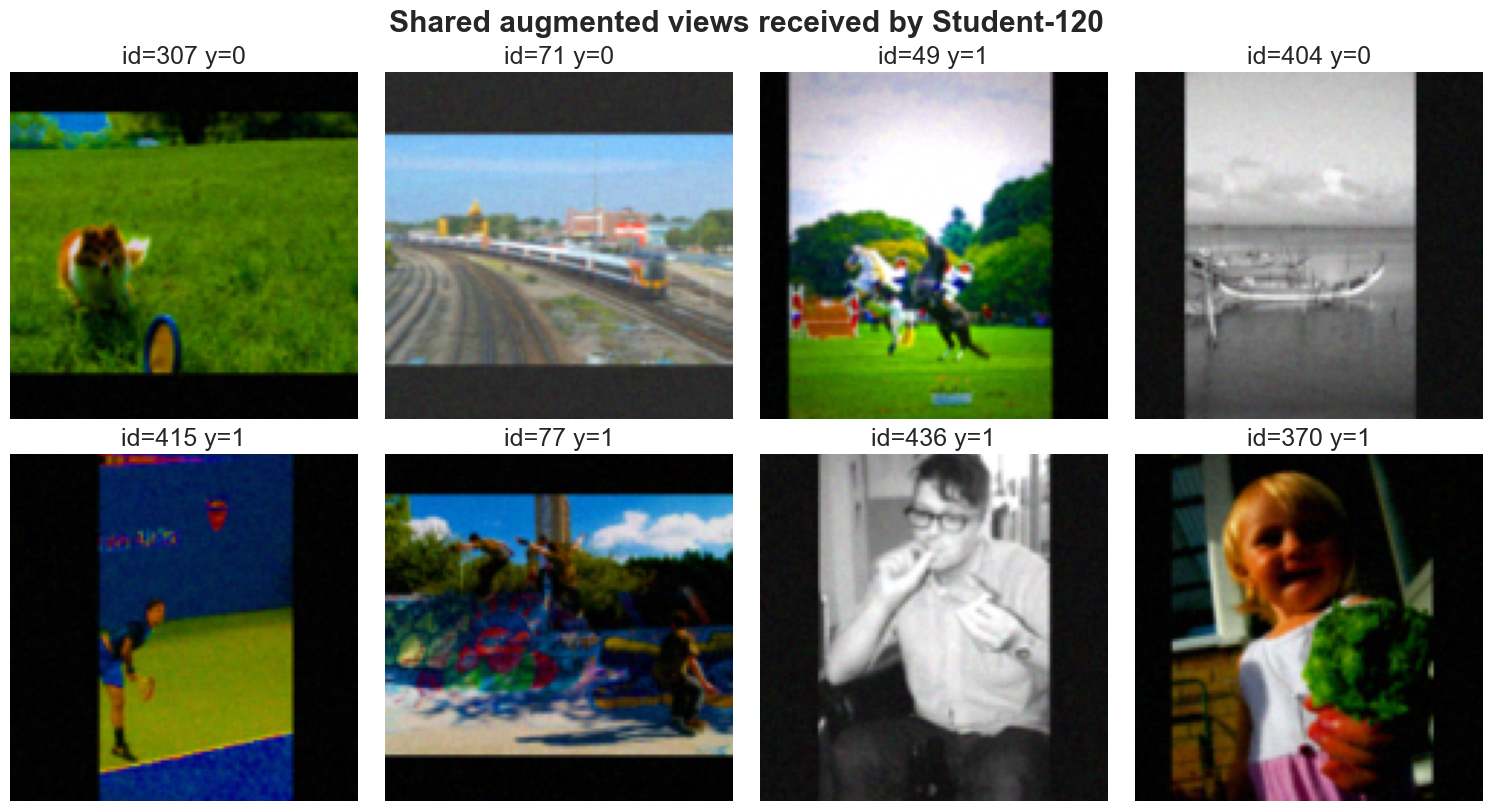

In [17]:
fig, axes = plt.subplots(2, 4, figsize=(15, 8), constrained_layout=True)
for index, axis in enumerate(axes.flat):
    axis.imshow(np.clip(preview_inputs["student_image"][index].numpy() / 255.0, 0, 1))
    axis.set_title(
        f'id={int(preview_targets["image_id"][index])} '
        f'y={int(preview_targets["label"][index, 0])}'
    )
    axis.axis("off")
fig.suptitle("Shared augmented views received by Student-120", fontweight="bold")
fig.savefig(FIGURE_DIR / "shared_view_samples.png", dpi=180, bbox_inches="tight")
plt.show()

assert preview_inputs["teacher_image"].shape[1:] == (*TEACHER_SIZE, 3)
assert preview_inputs["student_image"].shape[1:] == (*STUDENT_SIZE, 3)

## 4 · Exact student construction and inference graph

In [18]:
def build_student_core(legacy_augmentation_inside=False, weights="imagenet"):
    inputs = tf.keras.Input((*STUDENT_SIZE, 3), name="image")
    x = tf.keras.layers.Rescaling(1 / 127.5, offset=-1, name="normalize")(inputs)
    if legacy_augmentation_inside:
        x = legacy_augmentation(x)
    backbone = tf.keras.applications.MobileNet(
        input_tensor=x,
        input_shape=(*STUDENT_SIZE, 3),
        alpha=float(config["student"]["width_multiplier"]),
        include_top=False,
        weights=weights,
    )
    x = tf.keras.layers.GlobalAveragePooling2D(name="global_average")(backbone.output)
    x = tf.keras.layers.Dropout(float(config["student"]["dropout"]), name="student_dropout")(x)
    logits = tf.keras.layers.Dense(
        1,
        kernel_regularizer=tf.keras.regularizers.l2(float(config["student"]["l2"])),
        name="person_logit",
    )(x)
    return tf.keras.Model(inputs, logits, name="student_120_logits"), backbone

In [19]:
def probability_view(core, name="student_120_probability"):
    return tf.keras.Model(
        core.input,
        tf.keras.layers.Activation("sigmoid", name="person_probability")(core.output),
        name=name,
    )


def weighted_signature(model):
    return [(layer.name, tuple(tuple(v.shape) for v in layer.weights))
            for layer in model.layers if layer.weights]


def copy_weighted_layers(source, destination):
    source_by_name = {layer.name: layer for layer in source.layers if layer.weights}
    for layer in destination.layers:
        if layer.weights:
            layer.set_weights(source_by_name[layer.name].get_weights())

In [20]:
tf.keras.utils.set_random_seed(SEED)
probe_core, probe_backbone = build_student_core(legacy_augmentation_inside=False, weights=None)
probe_probability = probability_view(probe_core)
assert probe_probability.count_params() == control_model.count_params() == 218801
assert weighted_signature(probe_probability) == weighted_signature(control_model)

layers, liveness, static_profile = profile_model(probe_probability, batch_size=1, training_batch_size=BATCH_SIZE)
layers.to_csv(REPORT_DIR / "student_layer_profile_untrained.csv", index=False)
liveness.to_csv(REPORT_DIR / "student_activation_liveness_untrained.csv", index=False)
(REPORT_DIR / "student_static_profile_untrained.json").write_text(json.dumps(static_profile, indent=2))
display(pd.Series(static_profile).to_frame("value"))

,value
model_name,student_120_probability
layers,91
parameters,218801
trainable_parameters,213329
non_trainable_parameters,5472
float32_weight_bytes,875204
global_weight_sparsity,0.025014
global_weight_near_zero_fraction,0.025014
global_kernel_sparsity,0.0
global_kernel_near_zero_fraction,0.0


## 5 · Correct binary response-KD objective

In [21]:
def probability_to_logit(probability, epsilon=1e-6):
    probability = tf.clip_by_value(probability, epsilon, 1.0 - epsilon)
    return tf.math.log(probability) - tf.math.log1p(-probability)

In [22]:
def binary_kd_terms(
        labels, 
        teacher_logits, 
        student_logits, 
        temperature, 
        teacher_weight, 
        label_smoothing
):
    labels = tf.reshape(tf.cast(labels, tf.float32), (-1, 1))
    teacher_logits = tf.reshape(tf.cast(teacher_logits, tf.float32), (-1, 1))
    student_logits = tf.reshape(tf.cast(student_logits, tf.float32), (-1, 1))
    tf.debugging.assert_equal(tf.shape(labels), tf.shape(student_logits))
    tf.debugging.assert_equal(tf.shape(teacher_logits), tf.shape(student_logits))

    smoothed = labels * (1.0 - label_smoothing) + 0.5 * label_smoothing
    hard_loss = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(
        labels=smoothed, 
        logits=student_logits,
    ))

    teacher_soft = tf.clip_by_value(tf.sigmoid(teacher_logits / temperature), 1e-7, 1 - 1e-7)
    soft_ce = tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(
        labels=teacher_soft, 
        logits=student_logits / temperature,
    ))
    teacher_entropy = tf.reduce_mean(-(
        teacher_soft * tf.math.log(teacher_soft)
        + (1.0 - teacher_soft) * tf.math.log(1.0 - teacher_soft)
    ))
    soft_kl = soft_ce - teacher_entropy
    hard_component = (1.0 - teacher_weight) * hard_loss
    soft_component = teacher_weight * temperature**2 * soft_kl
    
    return hard_loss, soft_kl, hard_component, soft_component

In [23]:
# Mathematical invariants: equal logits -> zero KL; opposite logits -> larger KL;
# lambda=0 -> exact hard objective; all binary shapes remain [batch, 1].
labels_probe = tf.constant([0.0, 1.0])
teacher_probe = tf.constant([[-2.0], [3.0]])
student_equal = tf.identity(teacher_probe)
student_opposite = -teacher_probe

terms_equal = binary_kd_terms(labels_probe, teacher_probe, student_equal, 4.0, 0.5, 0.0)
terms_opposite = binary_kd_terms(labels_probe, teacher_probe, student_opposite, 4.0, 0.5, 0.0)
assert abs(float(terms_equal[1])) < 1e-6
assert float(terms_opposite[1]) > float(terms_equal[1])

terms_lambda0 = binary_kd_terms(labels_probe, teacher_probe, student_opposite, 4.0, 0.0, 0.0)
np.testing.assert_allclose(float(terms_lambda0[2]), float(terms_lambda0[0]), rtol=1e-6)
np.testing.assert_allclose(float(terms_lambda0[3]), 0.0, atol=1e-7)
print({"equal_kl": float(terms_equal[1]), "opposite_kl": float(terms_opposite[1])})

{'equal_kl': 0.0, 'opposite_kl': 0.19561374187469482}


## 6 · Distiller with online same-view teacher and gradient audit

In [24]:
class SameViewBinaryDistiller(tf.keras.Model):
    def __init__(self, student_core, teacher_model, temperature, teacher_weight,
                 label_smoothing, view_mode):
        super().__init__(name="same_view_binary_distiller")
        self.student_core = student_core
        self.teacher_model = teacher_model
        self.temperature = tf.constant(float(temperature), tf.float32)
        self.teacher_weight = tf.constant(float(teacher_weight), tf.float32)
        self.label_smoothing = tf.constant(float(label_smoothing), tf.float32)
        self.view_mode = view_mode

        names = [
            "loss", 
            "hard_loss", 
            "soft_loss_kl", 
            "hard_component", 
            "soft_component",
            "regularization", 
            "gradient_norm", 
            "hard_gradient_norm", 
            "soft_gradient_norm",
            "gradient_cosine"
        ]
        self.trackers = {name: tf.keras.metrics.Mean(name=name) for name in names}
        self.quality = [
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(curve="ROC", name="roc_auc"),
            tf.keras.metrics.AUC(curve="PR", name="pr_auc"),
        ]

    @property
    def metrics(self):
        return [*self.trackers.values(), *self.quality]

    def _teacher_logits(self, inputs, targets):
        if self.view_mode == "shared_online_teacher":
            probability = self.teacher_model(inputs["teacher_image"], training=False)
            return tf.stop_gradient(probability_to_logit(probability))
        return tf.reshape(targets["cached_teacher_logit"], (-1, 1))

    def _compute_losses(self, inputs, targets, training):
        student_logits = self.student_core(inputs["student_image"], training=training)
        teacher_logits = self._teacher_logits(inputs, targets)
        hard, soft, hard_part, soft_part = binary_kd_terms(
            targets["label"], teacher_logits, student_logits,
            self.temperature, self.teacher_weight, self.label_smoothing,
        )
        regularization = (tf.add_n(self.student_core.losses)
                          if self.student_core.losses else tf.constant(0.0))
        return student_logits, teacher_logits, hard, soft, hard_part, soft_part, regularization

    @staticmethod
    def _flatten_gradients(gradients):
        parts = [tf.reshape(g, [-1]) for g in gradients if g is not None]
        return tf.concat(parts, axis=0) if parts else tf.zeros([1], tf.float32)

    def train_step(self, data):
        inputs, targets = data
        with tf.GradientTape(persistent=True) as tape:
            values = self._compute_losses(inputs, targets, training=True)
            logits, _, hard, soft, hard_part, soft_part, regularization = values
            total = hard_part + soft_part + regularization
        variables = self.student_core.trainable_variables
        gradients = tape.gradient(total, variables)
        hard_gradients = tape.gradient(hard_part, variables)
        soft_gradients = tape.gradient(soft_part, variables)
        del tape
        pairs = [(g, v) for g, v in zip(gradients, variables) if g is not None]
        self.optimizer.apply_gradients(pairs)

        hard_vector = self._flatten_gradients(hard_gradients)
        soft_vector = self._flatten_gradients(soft_gradients)
        cosine = tf.math.divide_no_nan(
            tf.reduce_sum(hard_vector * soft_vector),
            tf.norm(hard_vector) * tf.norm(soft_vector),
        )
        measurements = {
            "loss": total, 
            "hard_loss": hard, 
            "soft_loss_kl": soft,
            "hard_component": hard_part, 
            "soft_component": soft_part,
            "regularization": regularization,
            "gradient_norm": tf.linalg.global_norm([g for g, _ in pairs]),
            "hard_gradient_norm": tf.linalg.global_norm([g for g in hard_gradients if g is not None]),
            "soft_gradient_norm": tf.linalg.global_norm([g for g in soft_gradients if g is not None]),
            "gradient_cosine": cosine,
        }
        for name, value in measurements.items():
            self.trackers[name].update_state(value)
        probabilities = tf.sigmoid(logits)
        labels = tf.reshape(targets["label"], (-1, 1))
        for metric in self.quality:
            metric.update_state(labels, probabilities)
        return {metric.name: metric.result() for metric in self.metrics}

    def test_step(self, data):
        inputs, targets = data
        logits, _, hard, soft, hard_part, soft_part, regularization = self._compute_losses(
            inputs, targets, training=False
        )
        total = hard_part + soft_part + regularization
        zeros = tf.constant(0.0)
        values = {"loss": total, "hard_loss": hard, "soft_loss_kl": soft,
                  "hard_component": hard_part, "soft_component": soft_part,
                  "regularization": regularization, "gradient_norm": zeros,
                  "hard_gradient_norm": zeros, "soft_gradient_norm": zeros,
                  "gradient_cosine": zeros}
        for name, value in values.items():
            self.trackers[name].update_state(value)
        probabilities = tf.sigmoid(logits)
        labels = tf.reshape(targets["label"], (-1, 1))
        for metric in self.quality:
            metric.update_state(labels, probabilities)
        return {metric.name: metric.result() for metric in self.metrics}

In [25]:
# One-batch finite-gradient smoke test. This does not modify an experiment checkpoint.
tf.keras.utils.set_random_seed(SEED)
smoke_core, _ = build_student_core(legacy_augmentation_inside=False, weights=None)
smoke = SameViewBinaryDistiller(
    smoke_core, teacher_probability_model, temperature=2.0, teacher_weight=0.25,
    label_smoothing=float(config["training"]["label_smoothing"]),
    view_mode="shared_online_teacher",
)
smoke.compile(optimizer=tf.keras.optimizers.Adam(1e-5))
smoke_batch = next(iter(make_dataset(
    splits["train"].iloc[:BATCH_SIZE], "shared_online_teacher", training=True
)))
smoke_metrics = smoke.train_step(smoke_batch)
assert all(np.isfinite(float(value)) for value in smoke_metrics.values())
display(pd.Series({key: float(value) for key, value in smoke_metrics.items()}).to_frame("value"))
del smoke, smoke_core

,value
loss,0.774876
hard_loss,0.820464
soft_loss_kl,0.159507
hard_component,0.615348
soft_component,0.159507
regularization,0.000021
gradient_norm,43.425007
hard_gradient_norm,33.951481
soft_gradient_norm,10.723239
gradient_cosine,0.848796


## 7 · Registered experiments and two-stage training

The full sweep is intentionally disabled by default. Enable optional runs only after the
`lambda0_equivalence` gate passes.

In [26]:
experiment_table = pd.DataFrame(config["experiments"])
if RUN_OPTIONAL_ABLATIONS:
    selected_experiments = experiment_table.copy()
else:
    selected_experiments = experiment_table[experiment_table.enabled_by_default].copy()
display(experiment_table)
print("Selected:", selected_experiments.name.tolist())

,name,view_mode,temperature,teacher_weight,enabled_by_default
0,lambda0_equivalence,legacy_student_view,1.0,0.00,True
1,cached_clean_no_augmentation_t4_l050,cached_clean_no_augmentation,4.0,0.50,False
2,same_view_lambda0,shared_hard_control,1.0,0.00,True
3,same_view_t2_l025,shared_online_teacher,2.0,0.25,True
4,same_view_t1_l025,shared_online_teacher,1.0,0.25,False
5,same_view_t4_l025,shared_online_teacher,4.0,0.25,False
6,same_view_t2_l050,shared_online_teacher,2.0,0.50,False


Selected: ['lambda0_equivalence', 'same_view_lambda0', 'same_view_t2_l025']


In [27]:
class StudentBestCheckpoint(tf.keras.callbacks.Callback):
    def __init__(self, path, monitor="val_pr_auc"):
        super().__init__()
        self.path = Path(path)
        self.monitor = monitor
        self.best = -np.inf

    def on_epoch_end(self, epoch, logs=None):
        current = (logs or {}).get(self.monitor)
        if current is not None and float(current) > self.best:
            self.best = float(current)
            self.model.student_core.save(self.path)


def callbacks_for(name, stage, checkpoint):
    monitor = config["training"]["monitor"]
    return [
        StudentBestCheckpoint(checkpoint, monitor=monitor),
        tf.keras.callbacks.EarlyStopping(
            monitor=monitor, mode="max",
            patience=int(config["training"]["early_stopping_patience"]),
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor=monitor, mode="max", factor=0.3,
            patience=int(config["training"]["reduce_lr_patience"]), min_lr=1e-7,
        ),
        tf.keras.callbacks.CSVLogger(LOG_DIR / f"{name}_{stage}.csv"),
        tf.keras.callbacks.TerminateOnNaN(),
    ]

In [28]:
def train_experiment(spec):
    name = spec["name"]
    view_mode = spec["view_mode"]
    legacy = view_mode == "legacy_student_view"
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)
    core, backbone = build_student_core(legacy_augmentation_inside=legacy)
    backbone_names = {layer.name for layer in backbone.layers}

    train_ds = make_dataset(splits["train"], view_mode, training=True)
    val_ds = make_dataset(splits["val"], view_mode, training=False)
    stage_a = CHECKPOINT_DIR / f"{name}_stage_a.keras"
    stage_b = CHECKPOINT_DIR / f"{name}_stage_b.keras"

    for layer in core.layers:
        if layer.name in backbone_names:
            layer.trainable = False

    if RUN_TRAINING and not (REUSE_CHECKPOINTS and stage_a.exists()):
        trainer = SameViewBinaryDistiller(
            core, 
            teacher_probability_model, 
            spec["temperature"], 
            spec["teacher_weight"],
            config["training"]["label_smoothing"], 
            view_mode,
        )
        trainer.compile(optimizer=tf.keras.optimizers.Adam(config["training"]["head_learning_rate"]))
        trainer.fit(
            train_ds, validation_data=val_ds,
            epochs=int(config["training"]["head_epochs"]),
            callbacks=callbacks_for(name, "stage_a", stage_a),
        )
    core = tf.keras.models.load_model(stage_a, compile=False)

    mobile_layers = [layer for layer in core.layers if layer.name in backbone_names]
    cutoff = max(0, len(mobile_layers) - int(config["training"]["fine_tune_last_layers"]))
    for index, layer in enumerate(mobile_layers):
        layer.trainable = index >= cutoff and not isinstance(layer, tf.keras.layers.BatchNormalization)

    if RUN_TRAINING and not (REUSE_CHECKPOINTS and stage_b.exists()):
        trainer = SameViewBinaryDistiller(
            core, teacher_probability_model, spec["temperature"], spec["teacher_weight"],
            config["training"]["label_smoothing"], view_mode,
        )
        trainer.compile(optimizer=tf.keras.optimizers.Adam(config["training"]["fine_tune_learning_rate"]))
        trainer.fit(
            train_ds, validation_data=val_ds,
            epochs=int(config["training"]["fine_tune_epochs"]),
            callbacks=callbacks_for(name, "stage_b", stage_b),
        )
    core = tf.keras.models.load_model(stage_b, compile=False)

    # Rebuild a clean inference graph; augmentation and teacher never enter deployment.
    clean_core, _ = build_student_core(legacy_augmentation_inside=False, weights=None)
    copy_weighted_layers(core, clean_core)
    clean_model = probability_view(clean_core, name=f"{name}_probability")
    model_path = MODEL_DIR / f"{name}.keras"
    clean_model.save(model_path)
    return model_path

trained_paths = {}
for spec in selected_experiments.to_dict("records"):
    print("TRAINING", spec["name"])
    trained_paths[spec["name"]] = train_experiment(spec)
trained_paths

TRAINING lambda0_equivalence


/var/folders/8s/5p551ggs4fb2kjgvk5kzysnr0000gn/T/ipykernel_22687/1829842156.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  backbone = tf.keras.applications.MobileNet(


Epoch 1/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 27s 64ms/step - accuracy: 0.5116 - gradient_cosine: 0.0000e+00 - gradient_norm: 2.9981 - hard_component: 0.9567 - hard_gradient_norm: 2.9981 - hard_loss: 0.9567 - loss: 0.9567 - pr_auc: 0.5192 - precision: 0.5127 - recall: 0.4667 - regularization: 1.8733e-05 - roc_auc: 0.5171 - soft_component: 0.0000e+00 - soft_gradient_norm: 0.0000e+00 - soft_loss_kl: 0.5767 - val_accuracy: 0.5725 - val_gradient_cosine: 0.0000e+00 - val_gradient_norm: 0.0000e+00 - val_hard_component: 0.7851 - val_hard_gradient_norm: 0.0000e+00 - val_hard_loss: 0.7851 - val_loss: 0.7851 - val_pr_auc: 0.5664 - val_precision: 0.5717 - val_recall: 0.5399 - val_regularization: 1.6936e-05 - val_roc_auc: 0.6136 - val_soft_component: 0.0000e+00 - val_soft_gradient_norm: 0.0000e+00 - val_soft_loss_kl: 0.4256 - learning_rate: 3.0000e-04
Epoch 2/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 24s 63ms/step - accuracy: 0.5842 - gradient_cosine: 0.0000e+00 - gradient_norm: 2.4149 - hard_component: 0.7643 - ha

/var/folders/8s/5p551ggs4fb2kjgvk5kzysnr0000gn/T/ipykernel_22687/1829842156.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  backbone = tf.keras.applications.MobileNet(


Epoch 1/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 90s 231ms/step - accuracy: 0.5151 - gradient_cosine: 0.0000e+00 - gradient_norm: 3.0634 - hard_component: 0.9518 - hard_gradient_norm: 3.0634 - hard_loss: 0.9518 - loss: 0.9519 - pr_auc: 0.5256 - precision: 0.5160 - recall: 0.4867 - regularization: 1.8608e-05 - roc_auc: 0.5275 - soft_component: 0.0000e+00 - soft_gradient_norm: 0.0000e+00 - soft_loss_kl: 0.5922 - val_accuracy: 0.6180 - val_gradient_cosine: 0.0000e+00 - val_gradient_norm: 0.0000e+00 - val_hard_component: 0.7217 - val_hard_gradient_norm: 0.0000e+00 - val_hard_loss: 0.7217 - val_loss: 0.7217 - val_pr_auc: 0.6277 - val_precision: 0.6045 - val_recall: 0.6582 - val_regularization: 1.6877e-05 - val_roc_auc: 0.6665 - val_soft_component: 0.0000e+00 - val_soft_gradient_norm: 0.0000e+00 - val_soft_loss_kl: 0.3687 - learning_rate: 3.0000e-04
Epoch 2/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 83s 221ms/step - accuracy: 0.6148 - gradient_cosine: 0.0000e+00 - gradient_norm: 2.4617 - hard_component: 0.7429 - 

/var/folders/8s/5p551ggs4fb2kjgvk5kzysnr0000gn/T/ipykernel_22687/1829842156.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  backbone = tf.keras.applications.MobileNet(


Epoch 1/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 135s 348ms/step - accuracy: 0.5142 - gradient_cosine: 0.7584 - gradient_norm: 3.0148 - hard_component: 0.7192 - hard_gradient_norm: 2.3179 - hard_loss: 0.9589 - loss: 0.9060 - pr_auc: 0.5208 - precision: 0.5157 - recall: 0.4658 - regularization: 1.8567e-05 - roc_auc: 0.5217 - soft_component: 0.1868 - soft_gradient_norm: 0.8302 - soft_loss_kl: 0.1868 - val_accuracy: 0.6240 - val_gradient_cosine: 0.0000e+00 - val_gradient_norm: 0.0000e+00 - val_hard_component: 0.5353 - val_hard_gradient_norm: 0.0000e+00 - val_hard_loss: 0.7138 - val_loss: 0.6804 - val_pr_auc: 0.6313 - val_precision: 0.6143 - val_recall: 0.6441 - val_regularization: 1.6761e-05 - val_roc_auc: 0.6695 - val_soft_component: 0.1451 - val_soft_gradient_norm: 0.0000e+00 - val_soft_loss_kl: 0.1451 - learning_rate: 3.0000e-04
Epoch 2/8
375/375 ━━━━━━━━━━━━━━━━━━━━ 121s 322ms/step - accuracy: 0.6173 - gradient_cosine: 0.6373 - gradient_norm: 2.3195 - hard_component: 0.5478 - hard_gradient_norm

{'lambda0_equivalence': PosixPath('/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/artifacts/distillation/response_kd_alignment_student_120/models/lambda0_equivalence.keras'),
 'same_view_lambda0': PosixPath('/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/artifacts/distillation/response_kd_alignment_student_120/models/same_view_lambda0.keras'),
 'same_view_t2_l025': PosixPath('/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/artifacts/distillation/response_kd_alignment_student_120/models/same_view_t2_l025.keras')}

## 8 · Training diagnostics and gradient conflict

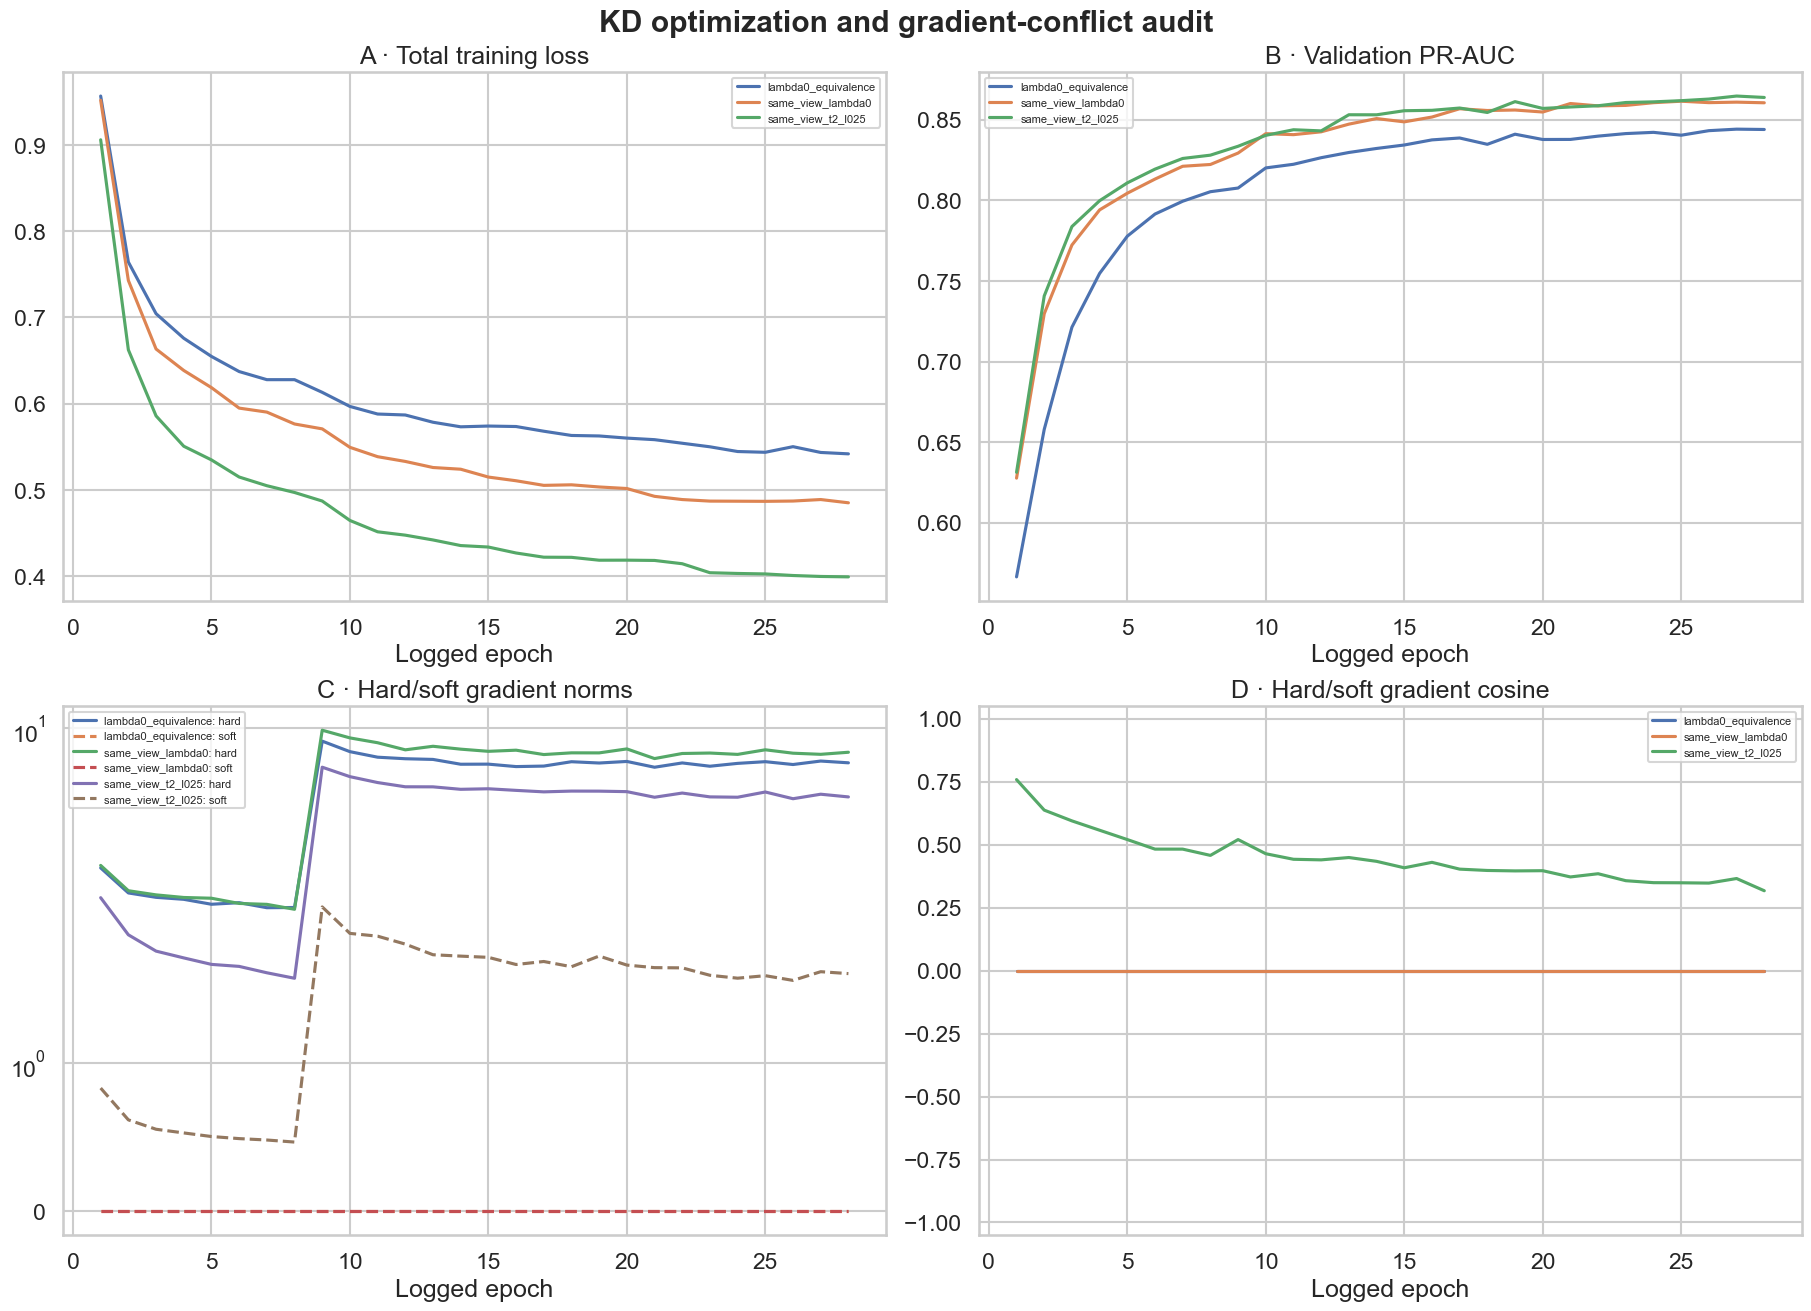

In [29]:
history_frames = []
for spec in selected_experiments.to_dict("records"):
    for stage in ("stage_a", "stage_b"):
        path = LOG_DIR / f"{spec['name']}_{stage}.csv"
        if path.exists():
            frame = pd.read_csv(path)
            frame["experiment"] = spec["name"]
            frame["stage"] = stage
            frame["combined_epoch"] = np.arange(len(frame)) + 1
            history_frames.append(frame)
history = pd.concat(history_frames, ignore_index=True) if history_frames else pd.DataFrame()
history.to_csv(REPORT_DIR / "training_history.csv", index=False)

if not history.empty:
    fig, axes = plt.subplots(2, 2, figsize=(18, 13), constrained_layout=True)
    for name, frame in history.groupby("experiment"):
        x = np.arange(len(frame)) + 1
        axes[0, 0].plot(x, frame.loss, label=name)
        axes[0, 1].plot(x, frame.val_pr_auc, label=name)
        axes[1, 0].plot(x, frame.hard_gradient_norm, label=f"{name}: hard")
        axes[1, 0].plot(x, frame.soft_gradient_norm, linestyle="--", label=f"{name}: soft")
        axes[1, 1].plot(x, frame.gradient_cosine, label=name)
    axes[0, 0].set(title="A · Total training loss", xlabel="Logged epoch")
    axes[0, 1].set(title="B · Validation PR-AUC", xlabel="Logged epoch")
    axes[1, 0].set(title="C · Hard/soft gradient norms", xlabel="Logged epoch", yscale="symlog")
    axes[1, 1].set(title="D · Hard/soft gradient cosine", xlabel="Logged epoch", ylim=(-1.05, 1.05))
    for axis in axes.flat: axis.legend(fontsize=8)
    fig.suptitle("KD optimization and gradient-conflict audit", fontweight="bold")
    fig.savefig(FIGURE_DIR / "training_and_gradient_audit.png", dpi=180, bbox_inches="tight")
    plt.show()

## 9 · Frozen validation and test evaluation

In [30]:
def make_student_eval_dataset(frame, batch_size=BATCH_SIZE):
    paths_array = frame.image_path.astype(str).to_numpy()
    labels_array = frame.label.astype("float32").to_numpy()
    ds = tf.data.Dataset.from_tensor_slices((paths_array, labels_array))
    ds = ds.map(lambda path, label: (letterbox(decode_rgb(path), STUDENT_SIZE), label),
                num_parallel_calls=AUTOTUNE)
    return ds.batch(batch_size).prefetch(AUTOTUNE)

val_eval_ds = make_student_eval_dataset(splits["val"])
test_eval_ds = make_student_eval_dataset(splits["test"])


def predict(model, dataset):
    labels = np.concatenate([np.asarray(y).reshape(-1) for _, y in dataset]).astype(int)
    probabilities = np.asarray(model.predict(dataset, verbose=0)).reshape(-1)
    return labels, probabilities

val_labels, control_val_probability = predict(control_model, val_eval_ds)
test_labels, control_test_probability = predict(control_model, test_eval_ds)
control_threshold_info = select_threshold(
    val_labels, 
    control_val_probability,
    objective=config["evaluation"]["threshold_objective"],
    minimum_recall=config["evaluation"]["minimum_recall"],
    false_positive_cost=config["evaluation"]["false_positive_cost"],
    false_negative_cost=config["evaluation"]["false_negative_cost"],
)
control_threshold = control_threshold_info["threshold"]
control_metrics = classification_metrics(test_labels, control_test_probability, control_threshold)
control_metrics["ece_10"] = expected_calibration_error(test_labels, control_test_probability)

prediction_table = pd.DataFrame({
    "image_id": splits["test"].image_id,
    "label": test_labels,
    "control_probability": control_test_probability,
})
quality_rows = [{"model": "hard_control", **control_metrics}]
thresholds = {"hard_control": control_threshold}

for name, model_path in trained_paths.items():
    model = tf.keras.models.load_model(model_path, compile=False)
    _, val_probability = predict(model, val_eval_ds)
    _, test_probability = predict(model, test_eval_ds)
    selected = select_threshold(
        val_labels, val_probability,
        objective=config["evaluation"]["threshold_objective"],
        minimum_recall=config["evaluation"]["minimum_recall"],
        false_positive_cost=config["evaluation"]["false_positive_cost"],
        false_negative_cost=config["evaluation"]["false_negative_cost"],
    )
    threshold = selected["threshold"]
    metrics = classification_metrics(test_labels, test_probability, threshold)
    metrics["ece_10"] = expected_calibration_error(test_labels, test_probability)
    quality_rows.append({"model": name, **metrics})
    thresholds[name] = threshold
    prediction_table[f"{name}_probability"] = test_probability

quality = pd.DataFrame(quality_rows)
quality.to_csv(REPORT_DIR / "quality_comparison.csv", index=False)
prediction_table.to_csv(REPORT_DIR / "paired_test_predictions.csv", index=False)
(REPORT_DIR / "validation_thresholds.json").write_text(json.dumps(thresholds, indent=2))
display(quality[["model", "threshold", "accuracy", "precision", "recall", "specificity", "f1", "pr_auc", "predicted_positive_rate"]])

,model,threshold,accuracy,precision,recall,specificity,f1,pr_auc,predicted_positive_rate
0,hard_control,0.275,0.7280,0.681027,0.837920,0.622179,0.751371,0.837142,0.6035
1,lambda0_equivalence,0.320,0.7415,0.709765,0.800204,0.684985,0.752276,0.839580,0.5530
2,same_view_lambda0,0.385,0.7815,0.777551,0.776758,0.786065,0.777155,0.865103,0.4900
3,same_view_t2_l025,0.340,0.7565,0.715532,0.835882,0.680079,0.771039,0.863546,0.5730


In [31]:
# Causal gate: lambda=0 must reproduce the hard control before KD is interpreted.
if "lambda0_equivalence" in quality.model.values:
    eq = quality.set_index("model").loc["lambda0_equivalence"]
    lambda0_gate = {
        "pr_auc_difference": float(eq.pr_auc - control_metrics["pr_auc"]),
        "f1_difference": float(eq.f1 - control_metrics["f1"]),
    }
    lambda0_gate["passed"] = bool(
        abs(lambda0_gate["pr_auc_difference"]) <= config["acceptance_gate"]["maximum_lambda0_pr_auc_difference"]
        and abs(lambda0_gate["f1_difference"]) <= config["acceptance_gate"]["maximum_lambda0_f1_difference"]
    )
else:
    lambda0_gate = {"passed": False, "reason": "lambda0 experiment not executed"}

(REPORT_DIR / "lambda0_equivalence_gate.json").write_text(json.dumps(lambda0_gate, indent=2))
print(lambda0_gate)
if not lambda0_gate["passed"]:
    print("STOP GATE: do not attribute later differences to KD until equivalence is repaired.")

{'pr_auc_difference': 0.002437129705089247, 'f1_difference': 0.0009048790764452086, 'passed': True}


## 10 · Paired bootstrap and fixed/broken decisions

In [32]:
def paired_bootstrap(labels, reference_prob, candidate_prob, reference_threshold, candidate_threshold,
                     samples=1000, seed=SEED):
    rng = np.random.default_rng(seed)
    rows = []
    indices = np.arange(len(labels))
    for iteration in range(samples):
        draw = rng.choice(indices, size=len(indices), replace=True)
        y = labels[draw]
        if len(np.unique(y)) < 2:
            continue
        reference = reference_prob[draw]
        candidate = candidate_prob[draw]
        rows.append({
            "iteration": iteration,
            "pr_auc_delta": average_precision_score(y, candidate) - average_precision_score(y, reference),
            "f1_delta": (
                f1_score(y, candidate >= candidate_threshold)
                - f1_score(y, reference >= reference_threshold)
            ),
        })
    return pd.DataFrame(rows)


def causal_reference(name):
    # The corrected KD variants must be compared with the corrected same-view
    # hard-label run. The legacy lambda-zero run is compared with Notebook 01.
    if name.startswith("same_view_") and name != "same_view_lambda0" and "same_view_lambda0" in trained_paths:
        return "same_view_lambda0"
    return "hard_control"


def probabilities_for(name):
    if name == "hard_control":
        return control_test_probability
    return prediction_table[f"{name}_probability"].to_numpy()

bootstrap_summaries = []
for name in trained_paths:
    reference = causal_reference(name)
    boot = paired_bootstrap(
        test_labels,
        probabilities_for(reference), probabilities_for(name),
        thresholds[reference], thresholds[name],
        samples=int(config["evaluation"]["bootstrap_samples"]),
    )
    boot.to_csv(REPORT_DIR / f"{name}_paired_bootstrap.csv", index=False)
    for metric in ("pr_auc_delta", "f1_delta"):
        values = boot[metric].to_numpy()
        bootstrap_summaries.append({
            "model": name, "reference": reference, "metric": metric, "mean": values.mean(),
            "ci_low": np.quantile(values, 0.025), "ci_high": np.quantile(values, 0.975),
            "probability_positive": np.mean(values > 0),
        })
bootstrap_summary = pd.DataFrame(bootstrap_summaries)
bootstrap_summary.to_csv(REPORT_DIR / "bootstrap_summary.csv", index=False)
display(bootstrap_summary)

,model,reference,metric,mean,ci_low,ci_high,probability_positive
0,lambda0_equivalence,hard_control,pr_auc_delta,0.002517,-0.004133,0.009350,0.766
1,lambda0_equivalence,hard_control,f1_delta,0.001165,-0.010194,0.012605,0.579
2,same_view_lambda0,hard_control,pr_auc_delta,0.028120,0.019426,0.038200,1.000
3,same_view_lambda0,hard_control,f1_delta,0.026193,0.010406,0.042375,1.000
4,same_view_t2_l025,same_view_lambda0,pr_auc_delta,-0.001590,-0.005711,0.002438,0.226
5,same_view_t2_l025,same_view_lambda0,f1_delta,-0.006310,-0.019281,0.006181,0.182


In [33]:
decision_rows = []
for name in trained_paths:
    reference = causal_reference(name)
    reference_probability = probabilities_for(reference)
    candidate_probability = probabilities_for(name)
    reference_correct = (reference_probability >= thresholds[reference]).astype(int) == test_labels
    candidate_correct = (candidate_probability >= thresholds[name]).astype(int) == test_labels
    decision_rows.append({
        "model": name,
        "reference": reference,
        "fixed_reference": int(np.sum(~reference_correct & candidate_correct)),
        "broke_reference": int(np.sum(reference_correct & ~candidate_correct)),
        "net_correct_change": int(np.sum(candidate_correct) - np.sum(reference_correct)),
    })
decision_changes = pd.DataFrame(decision_rows)
decision_changes.to_csv(REPORT_DIR / "paired_decision_changes.csv", index=False)
display(decision_changes)

,model,reference,fixed_reference,broke_reference,net_correct_change
0,lambda0_equivalence,hard_control,110,83,27
1,same_view_lambda0,hard_control,204,97,107
2,same_view_t2_l025,same_view_lambda0,66,116,-50


## 11 · Professional quality and false-positive dashboard

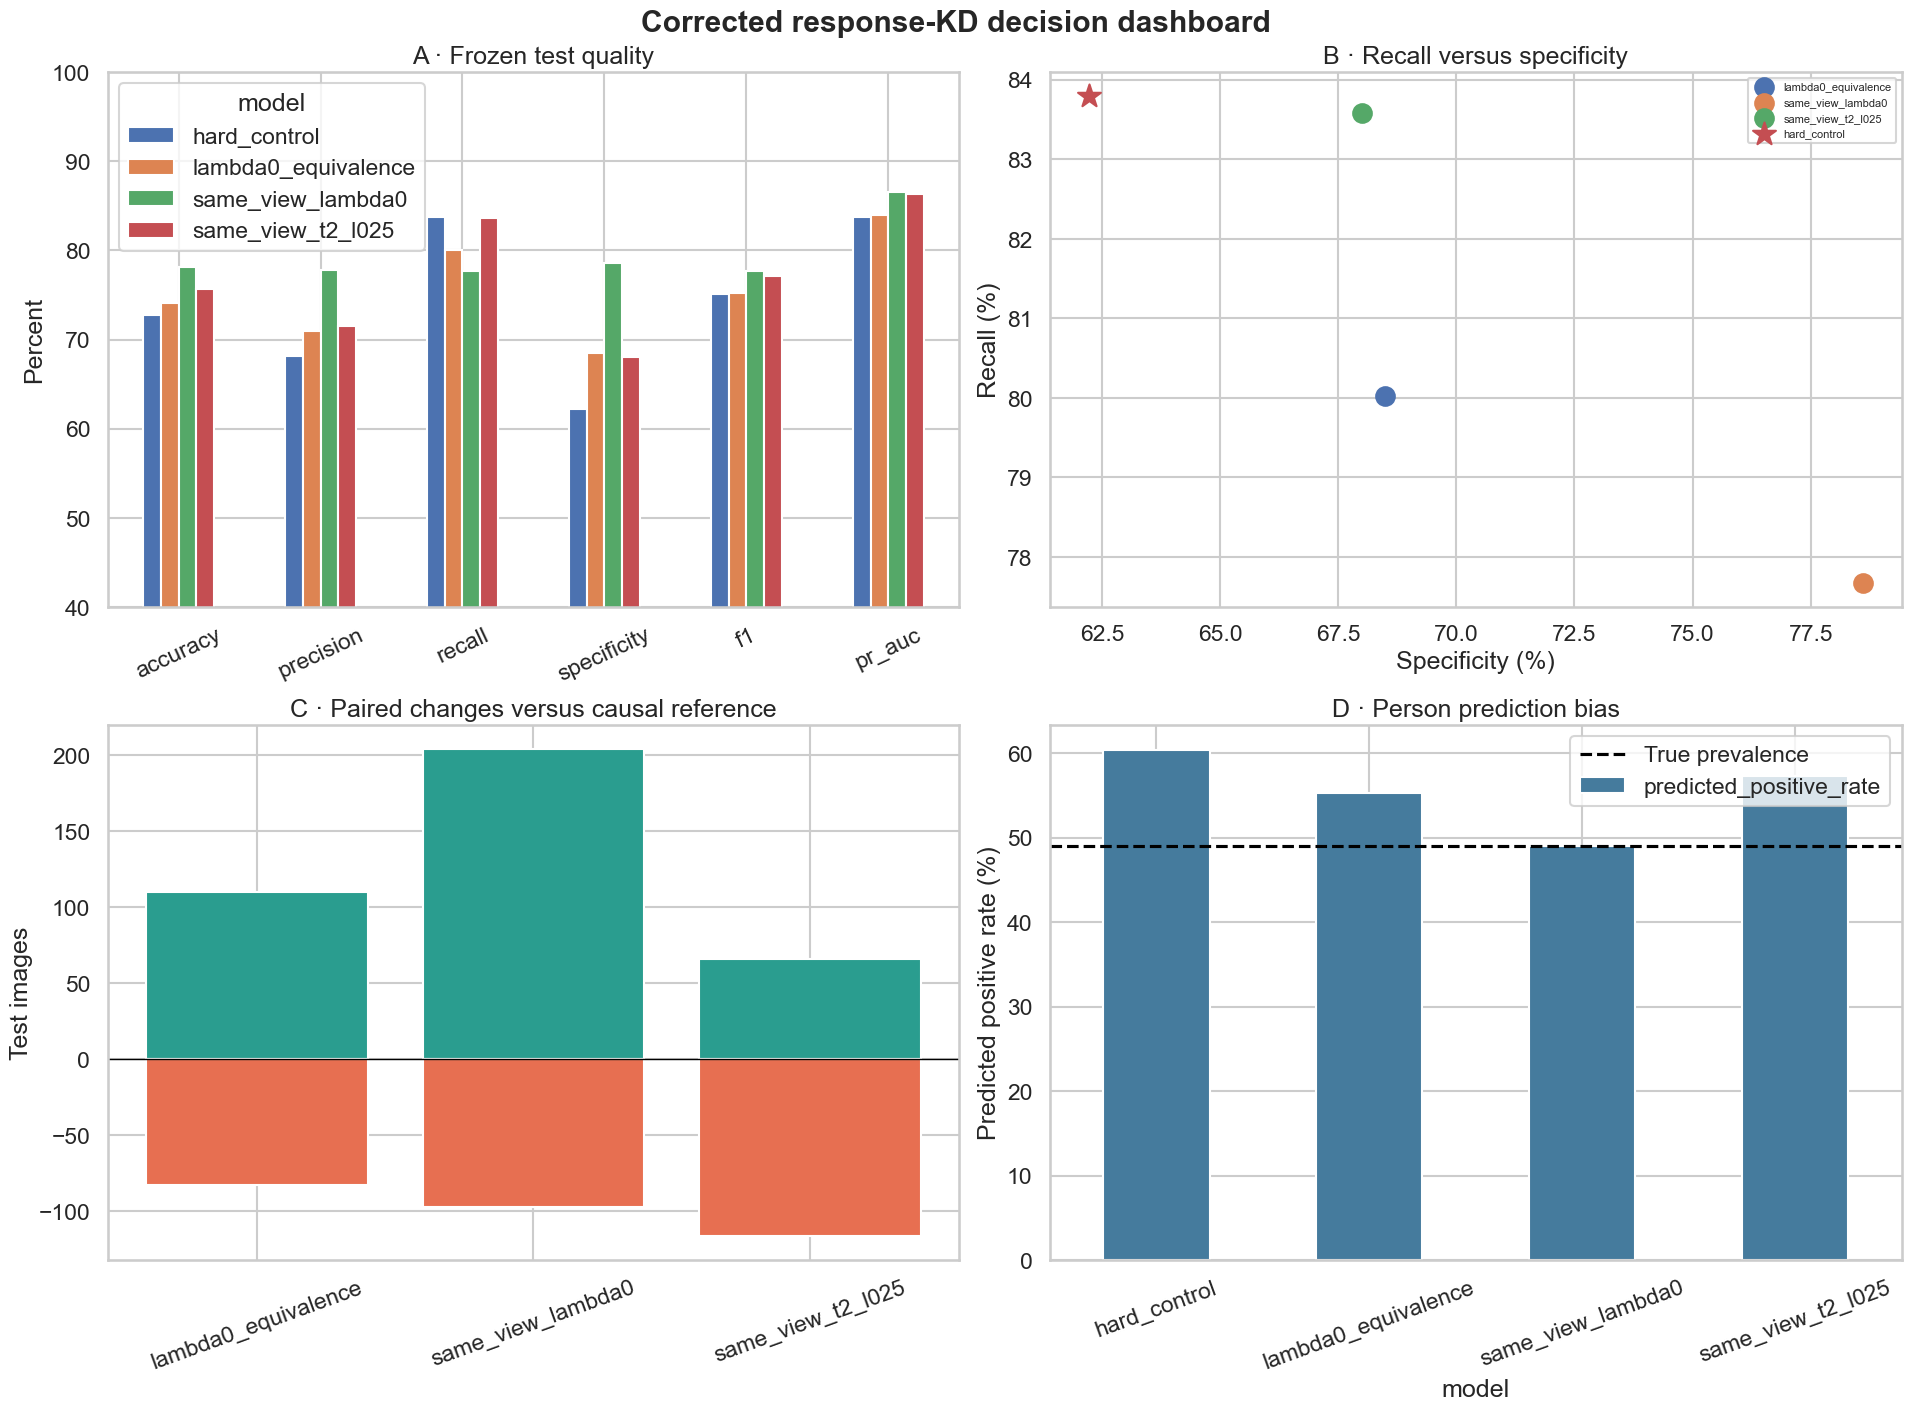

In [34]:
metrics_to_plot = ["accuracy", "precision", "recall", "specificity", "f1", "pr_auc"]
plot_quality = quality.set_index("model")[metrics_to_plot] * 100
fig, axes = plt.subplots(2, 2, figsize=(19, 14), constrained_layout=True)

plot_quality.T.plot(kind="bar", ax=axes[0, 0])
axes[0, 0].set(title="A · Frozen test quality", ylabel="Percent", ylim=(40, 100))
axes[0, 0].tick_params(axis="x", rotation=25)

for name in trained_paths:
    axes[0, 1].scatter(
        quality.set_index("model").loc[name, "specificity"] * 100,
        quality.set_index("model").loc[name, "recall"] * 100,
        s=180, label=name,
    )
axes[0, 1].scatter(control_metrics["specificity"] * 100, control_metrics["recall"] * 100,
                   marker="*", s=300, label="hard_control")
axes[0, 1].set(title="B · Recall versus specificity", xlabel="Specificity (%)", ylabel="Recall (%)")
axes[0, 1].legend(fontsize=8)

for row in decision_rows:
    axes[1, 0].bar(row["model"], row["fixed_reference"], color="#2a9d8f")
    axes[1, 0].bar(row["model"], -row["broke_reference"], color="#e76f51")
axes[1, 0].axhline(0, color="black", linewidth=1)
axes[1, 0].set(title="C · Paired changes versus causal reference", ylabel="Test images")
axes[1, 0].tick_params(axis="x", rotation=20)

positive_rate = quality.set_index("model")["predicted_positive_rate"] * 100
positive_rate.plot(kind="bar", ax=axes[1, 1], color="#457b9d")
axes[1, 1].axhline(test_labels.mean() * 100, color="black", linestyle="--", label="True prevalence")
axes[1, 1].set(title="D · Person prediction bias", ylabel="Predicted positive rate (%)")
axes[1, 1].legend()
axes[1, 1].tick_params(axis="x", rotation=20)

fig.suptitle("Corrected response-KD decision dashboard", fontweight="bold")
fig.savefig(FIGURE_DIR / "corrected_response_kd_dashboard.png", dpi=180, bbox_inches="tight")
plt.show()

## 12 · Person-size error slice

In [35]:
if "person_area_fraction" in splits["test"].columns:
    test_analysis = splits["test"][["image_id", "label", "person_area_fraction"]].copy()
    test_analysis = test_analysis.merge(prediction_table, on=["image_id", "label"])
    positive = test_analysis[test_analysis.label == 1].copy()
    positive["person_size"] = pd.cut(
        positive.person_area_fraction,
        bins=[-np.inf, 0.02, 0.10, np.inf], labels=["small", "medium", "large"],
    )
    slice_rows = []
    probability_columns = ["control_probability"] + [f"{name}_probability" for name in trained_paths]
    for size, frame in positive.groupby("person_size", observed=True):
        for column in probability_columns:
            name = "hard_control" if column == "control_probability" else column.removesuffix("_probability")
            recall = np.mean(frame[column].to_numpy() >= thresholds[name])
            slice_rows.append({"person_size": str(size), "model": name,
                               "samples": len(frame), "recall": recall})
    person_size = pd.DataFrame(slice_rows)
    person_size.to_csv(REPORT_DIR / "person_size_recall.csv", index=False)
    fig, axis = plt.subplots(figsize=(13, 7))
    sns.barplot(data=person_size, x="person_size", y="recall", hue="model", ax=axis)
    axis.set(title="Person-size recall after corrected KD", ylabel="Recall", xlabel="Person size", ylim=(0, 1))
    fig.savefig(FIGURE_DIR / "person_size_recall.png", dpi=180, bbox_inches="tight")
    plt.show()
else:
    print("person_area_fraction is unavailable; slice report skipped explicitly.")

person_area_fraction is unavailable; slice report skipped explicitly.


## 13 · Float acceptance gates

In [36]:
quality_by_model = quality.set_index("model")
float_gates = []
for name in trained_paths:
    row = quality_by_model.loc[name]
    reference_name = causal_reference(name)
    reference_row = quality_by_model.loc[reference_name]
    gates = {
        "model": name,
        "reference": reference_name,
        "lambda0_equivalence_passed": bool(lambda0_gate["passed"]),
        "pr_auc_gain": bool(row.pr_auc - reference_row.pr_auc >= config["acceptance_gate"]["minimum_float_pr_auc_gain"]),
        "f1_retained": bool(row.f1 >= reference_row.f1 - config["acceptance_gate"]["maximum_float_f1_drop"]),
        "specificity_retained": bool(row.specificity >= reference_row.specificity - config["acceptance_gate"]["maximum_specificity_drop"]),
    }
    gates["accepted_float"] = all(
        value for key, value in gates.items() if key not in {"model", "reference"}
    )
    float_gates.append(gates)
float_gate_table = pd.DataFrame(float_gates)
float_gate_table.to_csv(REPORT_DIR / "float_acceptance_gates.csv", index=False)
display(float_gate_table)

,model,reference,lambda0_equivalence_passed,pr_auc_gain,f1_retained,specificity_retained,accepted_float
0,lambda0_equivalence,hard_control,True,True,True,True,True
1,same_view_lambda0,hard_control,True,True,True,True,True
2,same_view_t2_l025,same_view_lambda0,True,False,False,False,False


## 14 · INT8 export for the accepted corrected candidate only

In [37]:
accepted_candidates = float_gate_table[
    (float_gate_table.accepted_float) & (~float_gate_table.model.isin(["lambda0_equivalence", "same_view_lambda0"]))
].model.tolist()
SELECTED_MODEL = accepted_candidates[0] if accepted_candidates else None
print("Selected for INT8:", SELECTED_MODEL)


def representative_generator(limit):
    count = 0
    for images, _ in val_eval_ds:
        for image in images:
            yield [image.numpy()[None, ...].astype(np.float32)]
            count += 1
            if count >= limit:
                return

TFLITE_PATH = MODEL_DIR / config["export"]["selected_model_filename"]
if SELECTED_MODEL and RUN_INT8_EXPORT:
    selected_float_model = tf.keras.models.load_model(trained_paths[SELECTED_MODEL], compile=False)
    convert_full_integer(
        selected_float_model,
        representative_generator(int(config["export"]["representative_samples"])),
        TFLITE_PATH,
    )
    export_info = inspect_tflite(TFLITE_PATH)
    (REPORT_DIR / "export_info.json").write_text(json.dumps(export_info, indent=2))
    display(pd.Series(export_info).to_frame("value"))
else:
    export_info = None
    print("INT8 export skipped: no corrected float candidate passed every gate.")

Selected for INT8: None
INT8 export skipped: no corrected float candidate passed every gate.


In [38]:
def predict_tflite(path, dataset):
    interpreter = tf.lite.Interpreter(model_path=str(path))
    interpreter.allocate_tensors()
    input_detail = interpreter.get_input_details()[0]
    output_detail = interpreter.get_output_details()[0]
    in_scale, in_zero = input_detail["quantization"]
    out_scale, out_zero = output_detail["quantization"]
    labels, probabilities = [], []
    for images, batch_labels in dataset:
        labels.extend(np.asarray(batch_labels).reshape(-1).astype(int))
        for image in np.asarray(images):
            quantized = np.clip(np.round(image / in_scale + in_zero), -128, 127).astype(np.int8)[None]
            interpreter.set_tensor(input_detail["index"], quantized)
            interpreter.invoke()
            raw = interpreter.get_tensor(output_detail["index"])[0, 0]
            probabilities.append((float(raw) - out_zero) * out_scale)
    return np.asarray(labels), np.asarray(probabilities)

if export_info:
    _, int8_val_probability = predict_tflite(TFLITE_PATH, val_eval_ds)
    _, int8_test_probability = predict_tflite(TFLITE_PATH, test_eval_ds)
    int8_threshold = select_threshold(
        val_labels, int8_val_probability,
        objective=config["evaluation"]["threshold_objective"],
        minimum_recall=config["evaluation"]["minimum_recall"],
        false_positive_cost=config["evaluation"]["false_positive_cost"],
        false_negative_cost=config["evaluation"]["false_negative_cost"],
    )["threshold"]
    int8_metrics = classification_metrics(test_labels, int8_test_probability, int8_threshold)
    float_probability = prediction_table[f"{SELECTED_MODEL}_probability"].to_numpy()
    parity = {
        "probability_mae": float(np.mean(np.abs(float_probability - int8_test_probability))),
        "f1_delta": float(int8_metrics["f1"] - quality_by_model.loc[SELECTED_MODEL, "f1"]),
        "pr_auc_delta": float(int8_metrics["pr_auc"] - quality_by_model.loc[SELECTED_MODEL, "pr_auc"]),
    }
    parity["probability_gate_passed"] = bool(
        parity["probability_mae"] <= config["acceptance_gate"]["maximum_float_to_int8_probability_mae"]
    )
    parity["f1_gate_passed"] = bool(
        parity["f1_delta"] >= -config["acceptance_gate"]["maximum_int8_f1_drop"]
    )
    (REPORT_DIR / "int8_metrics.json").write_text(json.dumps(int8_metrics, indent=2))
    (REPORT_DIR / "float_to_int8_parity.json").write_text(json.dumps(parity, indent=2))
    print({"int8_metrics": int8_metrics, "parity": parity})
else:
    int8_metrics, parity = None, None

## 15 · Static graph invariance and final report

In [39]:
graph_rows = []
for name, model_path in trained_paths.items():
    model = tf.keras.models.load_model(model_path, compile=False)
    _, _, profile = profile_model(model, batch_size=1, training_batch_size=BATCH_SIZE)
    graph_rows.append({
        "model": name,
        "parameters": profile["parameters"],
        "macs": profile["estimated_macs_batch1"],
        "peak_int8_activation_estimate": profile["peak_live_activation_int8_bytes_batch1_hypothetical"],
        "parameters_equal": profile["parameters"] == static_profile["parameters"],
        "macs_equal": profile["estimated_macs_batch1"] == static_profile["estimated_macs_batch1"],
    })
graph_identity = pd.DataFrame(graph_rows)
graph_identity.to_csv(REPORT_DIR / "graph_identity.csv", index=False)
display(graph_identity)

,model,parameters,macs,peak_int8_activation_estimate,parameters_equal,macs_equal
0,lambda0_equivalence,218801,10487648,117136,True,True
1,same_view_lambda0,218801,10487648,117136,True,True
2,same_view_t2_l025,218801,10487648,117136,True,True


In [ ]:
report = {
    "experiment": config["project"]["name"],
    "runtime_contract": runtime_contract,
    "lambda0_equivalence": lambda0_gate,
    "quality": quality.to_dict("records"),
    "float_gates": float_gate_table.to_dict("records"),
    "selected_for_int8": SELECTED_MODEL,
    "int8_metrics": int8_metrics,
    "float_to_int8_parity": parity,
    "physical_device_profile_complete": False,
}
(REPORT_DIR / "experiment_summary.json").write_text(json.dumps(report, indent=2))

lines = [
    "# Corrected same-view response-KD report", "",
    f"- Lambda-zero equivalence passed: **{lambda0_gate['passed']}**",
    f"- Selected float candidate: **{SELECTED_MODEL or 'none'}**",
    f"- Physical ESP32 profiling complete: **False**", "",
    "## Quality comparison", "", quality.to_markdown(index=False), "",
    "## Float acceptance gates", "", float_gate_table.to_markdown(index=False), "",
    "## Decision", "",
]
if SELECTED_MODEL:
    lines.append("The accepted candidate may proceed to INT8 parity and then physical profiling.")
else:
    lines.append("No corrected KD candidate passed every gate; do not deploy a KD artifact.")
(REPORT_DIR / "CORRECTED_RESPONSE_KD_REPORT.md").write_text("\n".join(lines))
print("Wrote", REPORT_DIR / "CORRECTED_RESPONSE_KD_REPORT.md")

## Next decision

- If the `lambda=0` gate fails, repair the training-pipeline equivalence before interpreting KD.
- If same-view `T=2, lambda=0.25` improves recall but breaks specificity, inspect gradient conflict
  and teacher false positives before increasing teacher weight.
- If the corrected response candidate passes float and INT8 gates, profile that exact FlatBuffer on
  ESP32-CAM and ESP32-S3 with flash disabled.
- If corrected response KD remains neutral, retain it as negative evidence and proceed to attention
  transfer, which carries spatial information absent from a single binary response.